# 📊 Telecom X - Análisis de Evasión de Clientes

Has sido contratado como asistente de análisis de datos en Telecom X y formarás parte del proyecto "Churn de Clientes". La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes.

Tu desafío será recopilar, procesar y analizar los datos, utilizando Python y sus principales bibliotecas para extraer información valiosa. A partir de tu análisis, el equipo de Data Science podrá avanzar en modelos predictivos y desarrollar estrategias para reducir la evasión.

## Instalación de librerías para graficar

In [ ]:
!pip install -U kaleido

In [ ]:
# Instalar Chrome y Kaleido compatibles
!apt-get install -y google-chrome-stable
!pip install -U plotly==6.1.1 kaleido

# Descargar Chrome para Kaleido (obligatorio en Colab)
!plotly_get_chrome


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package google-chrome-stable

Plotly will install a copy of Google Chrome to be used for generating static images of plots.
Chrome will be installed at: /usr/local/lib/python3.11/dist-packages/choreographer/cli/browser_exe
Do you want to proceed? [y/n] y
Installing Chrome for Plotly...
Chrome installed successfully.
The Chrome executable is now located at: /usr/local/lib/python3.11/dist-packages/choreographer/cli/browser_exe/chrome-linux64/chrome


In [ ]:
!pip install -U plotly==6.1.1 kaleido
import os
os.kill(os.getpid(), 9)  # Reinicia el runtime automáticamente

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 92.1 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [ ]:
import os
os.kill(os.getpid(), 9)

#📌 Extracción

In [ ]:
#importacion de los datos mediante pandas
import pandas as pd
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
df = pd.read_json(url)

In [ ]:
#muestra los 10 primeros registros
df.head(10)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
5,0013-MHZWF,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
6,0013-SMEOE,No,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Two year', 'PaperlessBilling': '..."
7,0014-BMAQU,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Two year', 'PaperlessBilling': '..."
8,0015-UOCOJ,No,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
9,0016-QLJIS,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [ ]:
#muestra la informacion del dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [ ]:
#Crea varios data frame normalizados
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

In [ ]:
#Elimia columnas y une los dataframe normalizados
df   = pd.concat([
    df.drop(columns=['customer', 'phone', 'internet', 'account']),  # columnas originales
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)

In [ ]:
df #muestra data frame con los registros normalizados

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


#🔧 Transformación

In [ ]:
#verifica si tiene valores nulos
df['Charges.Total'].isnull().sum()

np.int64(0)

In [ ]:
(df['Charges.Total'].astype(str).str.strip() == '').sum()

np.int64(11)

In [ ]:
#limpia los valores si existen "," "simbolos", "." convierte valores a float

In [ ]:
"""Si x es vacío ('' o solo espacios) o nulo (NaN), devuelve 0.

Si tiene texto como '$1,234.56', lo limpia a '1234.56'.

Finalmente convierte todo a float."""

def limpiar_valor(x):
    if pd.isna(x) or str(x).strip() == '':
        return 0
    else:
        return str(x).replace('$', '').replace(',', '').strip()

df['Charges.Total'] = df['Charges.Total'].apply(limpiar_valor).astype(float)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [ ]:
#verificar valores unicos
for col in df.columns:
    print(f"Columna: {col}")
    print(df[col].unique())  # Muestra los valores únicos
    print(f"Cantidad de valores únicos: {df[col].nunique()}")
    print("-" * 50)

Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
Cantidad de valores únicos: 7267
--------------------------------------------------
Columna: Churn
['No' 'Yes' '']
Cantidad de valores únicos: 3
--------------------------------------------------
Columna: gender
['Female' 'Male']
Cantidad de valores únicos: 2
--------------------------------------------------
Columna: SeniorCitizen
[0 1]
Cantidad de valores únicos: 2
--------------------------------------------------
Columna: Partner
['Yes' 'No']
Cantidad de valores únicos: 2
--------------------------------------------------
Columna: Dependents
['Yes' 'No']
Cantidad de valores únicos: 2
--------------------------------------------------
Columna: tenure
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
Cantidad 

In [ ]:
# Ver si hay filas duplicadas
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

# Opcional: mostrar las filas duplicadas
if duplicados > 0:
    print(df[df.duplicated()])

Filas duplicadas: 0


In [ ]:
# Contar valores nulos por columna
nulos_por_columna = df.isnull().sum()
print("Valores nulos por columna:\n", nulos_por_columna)

# Contar el total de valores nulos en todo el DataFrame
total_nulos = df.isnull().sum().sum()
print(f"Total de valores nulos: {total_nulos}")

Valores nulos por columna:
 customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64
Total de valores nulos: 0


In [ ]:
# Detectar valores vacíos o en blanco en cada columna
valores_blancos = (df.astype(str).apply(lambda x: x.str.strip() == '')).sum()

print("Valores vacíos o en blanco por columna:")
print(valores_blancos)

# Contar el total en todo el DataFrame
total_blancos = valores_blancos.sum()
print(f"Total de valores vacíos o en blanco: {total_blancos}")

Valores vacíos o en blanco por columna:
customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
Charges.Monthly       0
Charges.Total         0
dtype: int64
Total de valores vacíos o en blanco: 224


In [ ]:
# Eliminar filas con NaN o espacios en blanco en la columna 'Churn'
df = df[df['Churn'].notna()]  # Quita NaN
df = df[df['Churn'].str.strip() != '']  # Quita valores vacíos en texto


In [ ]:
# Detectar valores vacíos o en blanco en cada columna
valores_blancos = (df.astype(str).apply(lambda x: x.str.strip() == '')).sum()

print("Valores vacíos o en blanco por columna:")
print(valores_blancos)

# Contar el total en todo el DataFrame
total_blancos = valores_blancos.sum()
print(f"Total de valores vacíos o en blanco: {total_blancos}")

Valores vacíos o en blanco por columna:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64
Total de valores vacíos o en blanco: 0


In [ ]:
"""
# Eliminar filas con cualquier valor nulo
df = df.dropna()

# Adicional: eliminar filas con strings vacíos en cualquier columna tipo texto
df = df[~(df.select_dtypes(include='object').apply(lambda x: x.str.strip() == '').any(axis=1))]
"""

"\n# Eliminar filas con cualquier valor nulo\ndf = df.dropna()\n\n# Adicional: eliminar filas con strings vacíos en cualquier columna tipo texto\ndf = df[~(df.select_dtypes(include='object').apply(lambda x: x.str.strip() == '').any(axis=1))]\n"

In [ ]:
# Crear la nueva columna "Cuentas_Diarias"
df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30

# Opcional: redondear a 2 decimales
df['Cuentas_Diarias'] = df['Cuentas_Diarias'].round(2)

In [ ]:
df.sample(2)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
1112,1571-SAVHK,Yes,Male,0,No,No,12,Yes,Yes,Fiber optic,...,No,Yes,Yes,Yes,Month-to-month,Yes,Mailed check,99.95,1132.75,3.33
5362,7321-PKUYW,Yes,Female,0,No,No,11,Yes,Yes,Fiber optic,...,No,Yes,Yes,No,Month-to-month,No,Electronic check,90.15,987.95,3.01


In [ ]:
# Verificar Total SI y NO antes del cambio
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
#normalizar columna churn SI = 1 Y NO = 0
df['Churn'] = df['Churn'].str.strip().str.capitalize().replace({'Yes': 1, 'No': 0})
# Verificar los cambios
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


/tmp/ipython-input-3016611631.py:2: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

#📊 Carga y análisis

In [ ]:
#Calculando la media, mediana, desviacion estandar
df.describe()

,Churn,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,32.371149,64.761692,2279.734304,2.158675
std,0.441561,0.368612,24.559481,30.090047,2266.794470,1.003088
min,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,9.000000,35.500000,398.550000,1.180000
50%,0.000000,0.000000,29.000000,70.350000,1394.550000,2.340000
75%,1.000000,0.000000,55.000000,89.850000,3786.600000,2.990000
max,1.000000,1.000000,72.000000,118.750000,8684.800000,3.960000


In [ ]:
#Graficando
import plotly.express as px

# Crear columna categórica con etiquetas legibles
df['Evasión'] = df['Churn'].map({0: 'Permaneció', 1: 'Abandono'})

# Crear gráfica interactiva
fig = px.histogram(
    df,
    x="Churn",
    color="Evasión",
    title="Distribución Evasión de Clientes",
    text_auto=True,
    barmode='group',
)

fig.update_layout(
    title='Distribución de Evasión',
    title_x=0.5,
    xaxis_title='Evasión',
    yaxis_title='Número de Clientes',
    xaxis=dict(
        tickvals=['0', '1'],
        ticktext=['No', 'Si']
    )
)

# Guardar como imagen PNG alta resolución
#fig.write_image("Distribucion_evasion.png", scale=3)

# Mostrar
fig.show()

In [ ]:
import plotly.express as px

# Crear columna categórica con etiquetas legibles
df['Evasión'] = df['Churn'].map({0: 'Permaneció', 1: 'Abandono'})
# Crear diagrama de pastel
fig = px.pie(
    df,
    names='Evasión',
    title='Distribución Evasión de Clientes',
    color='Evasión',
    hole=0  # Si quieres un gráfico de dona, pon hole=0.4
)

# Guardar como imagen PNG alta resolución
#fig.write_image("Distribucion_evasion_pastel.png", scale=3)

# Mostrar
fig.show()

In [ ]:
import plotly.express as px
# Crear columna categórica con etiquetas legibles
df['Evasión'] = df['Churn'].map({0: 'Permaneció', 1: 'Abandono'})

fig = px.histogram(df, x='gender', text_auto=True, color='Evasión', barmode='group')

fig.update_layout(
    title='Distribución de Evación por Género',
    title_x=0.5,
    xaxis_title='Género',
    yaxis_title='Número de Clientes',
    xaxis=dict(
        tickvals=['Male', 'Female'],
        ticktext=['Hombres', 'Mujeres']
    )
)

# Guardar como imagen PNG alta resolución
#fig.write_image("Distribucion_evasion_genero.png", scale=3)

fig.show()

In [ ]:
#CLIENTES MAYOR A 65
# Crear columna categórica con etiquetas legibles
df['Evasión'] = df['Churn'].map({0: 'Permaneció', 1: 'Abandono'})

fig = px.histogram(df, x='SeniorCitizen', text_auto=True, color='Evasión', barmode='group')

fig.update_layout(
    title='Distribución de Clientes Mayor a 65 Años',
    title_x=0.5,
    xaxis_title='Menor y Mayor 65 Años',
    yaxis_title='Número de Clientes',
    xaxis=dict(
        tickvals=['0', '1'],
        ticktext=['Menor a 65 años', 'Mayor a 65 años']
    )
)
# Guardar como imagen PNG alta resolución
#fig.write_image("Distribucion_evasion_65.png", scale=3)

fig.show()

In [ ]:
#MESES DE CONTRATO
# Crear columna categórica con etiquetas legibles
df['Evasión'] = df['Churn'].map({0: 'Permaneció', 1: 'Abandono'})

fig = px.histogram(df, x='tenure', text_auto=True, color='Evasión', barmode='group')

fig.update_layout(
    title='Distribución de Clientes por Meses de Contrato',
    title_x=0.5,
    xaxis_title='Tiempo en Meses de Contrato',
    yaxis_title='Número de Clientes',
    #xaxis=dict(
     #   tickvals=['0', '1'],
      #  ticktext=['No', 'Si']
    #)
)
# Guardar como imagen PNG alta resolución
#fig.write_image("Distribucion_evasion_mes_contrato.png", scale=3)

fig.show()

In [ ]:
# Agrupar por tenure y Churn
df_grouped = df.groupby(['tenure', 'Churn']).size().unstack(fill_value=0)

# Mostrar columnas para confirmar
print(df_grouped.columns)

# Calcular % churn (columna 1 es churn = sí)
df_grouped['churn_rate'] = (df_grouped.get(1, 0) / df_grouped.sum(axis=1)) * 100

# Mostrar resultado
print(df_grouped[['churn_rate']])

Index([0, 1], dtype='int64', name='Churn')
Churn   churn_rate
tenure            
0         0.000000
1        61.990212
2        51.680672
3        47.000000
4        47.159091
...            ...
68        9.000000
69        8.421053
70        9.243697
71        3.529412
72        1.657459

[73 rows x 1 columns]


In [ ]:
fig = px.line(df_grouped.reset_index(),
              x='tenure',
              y='churn_rate',
              markers=True,
              title='Tasa de Evasion (%) por Tiempo de contrato')

fig.update_layout(
    title='Tasa de Evasion (%) por Tiempo de Contrato',
    title_x=0.5,
    xaxis_title='Tiempo en Meses de Contrato',
    yaxis_title='Tasa de Evasion (%)',
)
# Guardar como imagen PNG alta resolución
#fig.write_image("Distribucion_evasion_tasa.png", scale=3)
fig.show()

Distribución de Evasión según Servicio telefónico (PhoneService):
  PhoneService      Churn
1          Yes  26.709637
0           No  24.926686


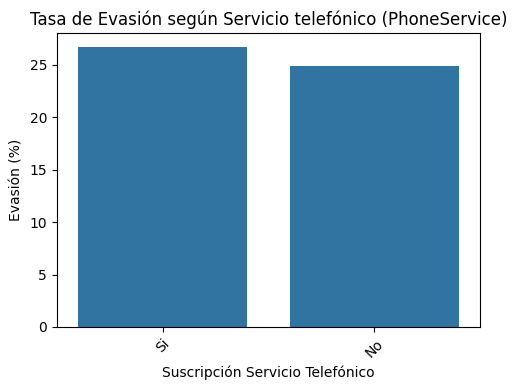

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# PhoneService
tabla_phone = df.groupby("PhoneService")["Churn"].mean().reset_index()
tabla_phone["Churn"] = tabla_phone["Churn"] * 100

print("Distribución de Evasión según Servicio telefónico (PhoneService):")
print(tabla_phone.sort_values(by="Churn", ascending=False))

plt.figure(figsize=(5,4))
sns.barplot(x="PhoneService", y="Churn", data=tabla_phone, order=tabla_phone.sort_values("Churn", ascending=False)["PhoneService"])
plt.title("Tasa de Evasión según Servicio telefónico (PhoneService)")
plt.ylabel("Evasión (%)")
plt.xlabel("Suscripción Servicio Telefónico")
plt.xticks(rotation=45)
plt.xticks(ticks=[0, 1], labels=["Si", "No"])
plt.tight_layout()
# Guardar el gráfico como imagen PNG de alta resolución
plt.savefig("evasion_phonservice.png", dpi=300, bbox_inches="tight")
plt.show()


Interpretación esperada:
Si la tasa es similar entre “Yes” y “No”, PhoneService no es un factor determinante. Si una de las dos tiene mucho más churn, podría indicar que tener o no tener teléfono está asociado con la permanencia.

Distribución de Evasión según Suscrito a más de una línea telefónica:
      MultipleLines      Churn
2               Yes  28.609896
0                No  25.044248
1  No phone service  24.926686


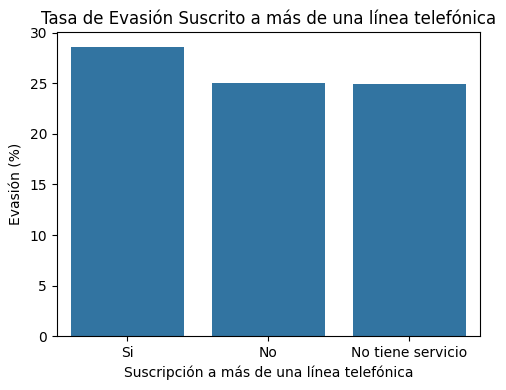

In [ ]:
tabla_ml = df.groupby("MultipleLines")["Churn"].mean().reset_index()
tabla_ml["Churn"] = tabla_ml["Churn"] * 100

print("Distribución de Evasión según Suscrito a más de una línea telefónica:")
print(tabla_ml.sort_values(by="Churn", ascending=False))

plt.figure(figsize=(5,4))
sns.barplot(x="MultipleLines", y="Churn", data=tabla_ml, order=tabla_ml.sort_values("Churn", ascending=False)["MultipleLines"])
plt.title("Tasa de Evasión Suscrito a más de una línea telefónica")
plt.ylabel("Evasión (%)")
plt.xticks(ticks=[0, 1, 2], labels=["Si", "No", "No tiene servicio"])
plt.xlabel("Suscripción a más de una línea telefónica")
plt.tight_layout()

# Guardar el gráfico como imagen PNG de alta resolución
plt.savefig("evasion_multiplesLines.png", dpi=300, bbox_inches="tight")
plt.show()


Podrías encontrar que clientes con “No phone service” o sin líneas múltiples tienen churn diferente. Si el churn es mayor en quienes no tienen múltiples líneas, podría indicar menos compromiso con la empresa.



Distribución de Evasión Subscrito a un Proveedor de Internet:
  InternetService      Churn
1     Fiber optic  41.892765
0             DSL  18.959108
2              No   7.404980


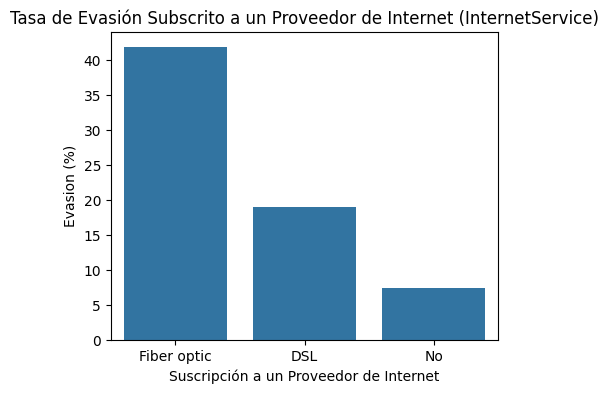

In [ ]:
tabla_int = df.groupby("InternetService")["Churn"].mean().reset_index()
tabla_int["Churn"] = tabla_int["Churn"] * 100

print("Distribución de Evasión Subscrito a un Proveedor de Internet:")
print(tabla_int.sort_values(by="Churn", ascending=False))

plt.figure(figsize=(5,4))
sns.barplot(x="InternetService", y="Churn", data=tabla_int, order=tabla_int.sort_values("Churn", ascending=False)["InternetService"])
plt.title("Tasa de Evasión Subscrito a un Proveedor de Internet (InternetService)")
plt.ylabel("Evasion (%)")
plt.xticks(ticks=[0, 1, 2], labels=["Fiber optic", "DSL", "No"])
plt.xlabel("Suscripción a un Proveedor de Internet")

# Guardar el gráfico como imagen PNG de alta resolución
plt.savefig("evasion_internetservices.png", dpi=300, bbox_inches="tight")
plt.show()


Interpretación esperada:
Suele pasar que quienes tienen “Fiber optic” presentan mayor Evasión que “DSL” o “No”, posiblemente por costos o calidad percibida.

Distribución de Evasión Subscrito a Seguridad en Linea (OnlineSecurity):
        OnlineSecurity      Churn
0                   No  41.766724
2                  Yes  14.611194
1  No internet service   7.404980


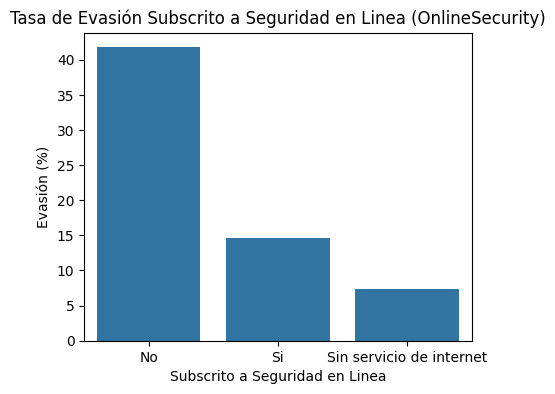

In [ ]:
tabla_sec = df.groupby("OnlineSecurity")["Churn"].mean().reset_index()
tabla_sec["Churn"] = tabla_sec["Churn"] * 100

print("Distribución de Evasión Subscrito a Seguridad en Linea (OnlineSecurity):")
print(tabla_sec.sort_values(by="Churn", ascending=False))

plt.figure(figsize=(5,4))
sns.barplot(x="OnlineSecurity", y="Churn", data=tabla_sec, order=tabla_sec.sort_values("Churn", ascending=False)["OnlineSecurity"])
plt.title("Tasa de Evasión Subscrito a Seguridad en Linea (OnlineSecurity)")
plt.ylabel("Evasión (%)")
plt.xticks(ticks=[0, 1, 2], labels=["No", "Si", "Sin servicio de internet"])
plt.xlabel("Subscrito a Seguridad en Linea")
# Guardar el gráfico como imagen PNG de alta resolución
plt.savefig("onlinesecurity.png", dpi=300, bbox_inches="tight")
plt.show()


Interpretación esperada:
Clientes sin seguridad en línea probablemente tengan más Evasión; esto suele indicar que tener servicios adicionales genera más fidelidad.

Distribución Evasión según Subscrito Respaldo en linea (OnlineBackup):
          OnlineBackup      Churn
0                   No  39.928756
2                  Yes  21.531494
1  No internet service   7.404980


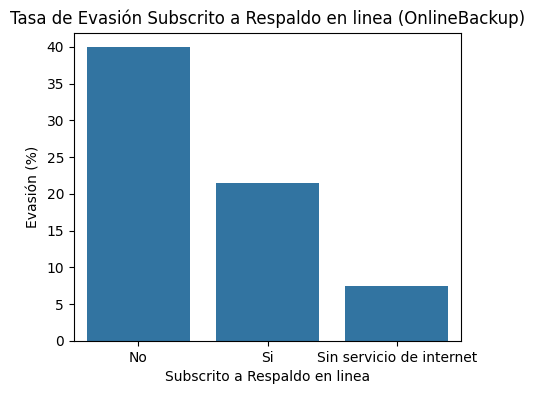

In [ ]:
tabla_bk = df.groupby("OnlineBackup")["Churn"].mean().reset_index()
tabla_bk["Churn"] = tabla_bk["Churn"] * 100

print("Distribución Evasión según Subscrito Respaldo en linea (OnlineBackup):")
print(tabla_bk.sort_values(by="Churn", ascending=False))

plt.figure(figsize=(5,4))
sns.barplot(x="OnlineBackup", y="Churn", data=tabla_bk, order=tabla_bk.sort_values("Churn", ascending=False)["OnlineBackup"])
plt.title("Tasa de Evasión Subscrito a Respaldo en linea (OnlineBackup)")
plt.ylabel("Evasión (%)")
plt.xlabel("Subscrito a Respaldo en linea")
plt.xticks(ticks=[0, 1, 2], labels=["No", "Si", "Sin servicio de internet"])

# Guardar el gráfico como imagen PNG de alta resolución
plt.savefig("evasion_onlinebackup.png", dpi=300, bbox_inches="tight")
plt.show()


Interpretación esperada:
Al igual que OnlineSecurity, la falta de respaldo online podría correlacionar con más churn.

Distribución de Evasión Subscrito a Protección de Dispositivo:
      DeviceProtection      Churn
0                   No  39.127625
2                  Yes  22.502064
1  No internet service   7.404980


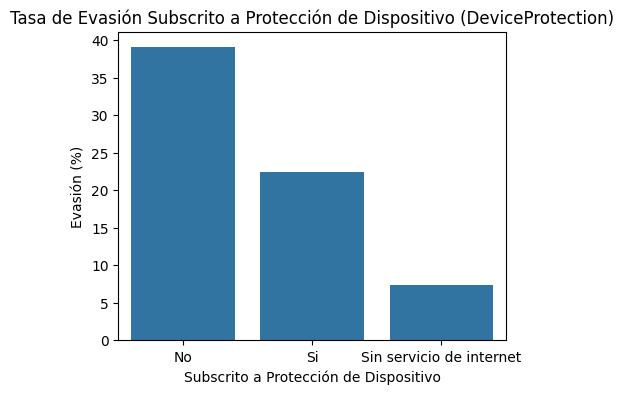

In [ ]:
tabla_dp = df.groupby("DeviceProtection")["Churn"].mean().reset_index()
tabla_dp["Churn"] = tabla_dp["Churn"] * 100

print("Distribución de Evasión Subscrito a Protección de Dispositivo:")
print(tabla_dp.sort_values(by="Churn", ascending=False))

plt.figure(figsize=(5,4))
sns.barplot(
    x="DeviceProtection",
    y="Churn",
    data=tabla_dp,
    order=tabla_dp.sort_values("Churn", ascending=False)["DeviceProtection"]
)
plt.title("Tasa de Evasión Subscrito a Protección de Dispositivo (DeviceProtection)")
plt.ylabel("Evasión (%)")
plt.xlabel("Subscrito a Protección de Dispositivo")
plt.xticks(ticks=[0, 1, 2], labels=["No", "Si", "Sin servicio de internet"])

# Guardar el gráfico como imagen PNG de alta resolución
plt.savefig("evasion_deviceprotection", dpi=300, bbox_inches="tight")
plt.show()


Interpretación esperada:
Quienes no tienen protección de dispositivo suelen mostrar tasas más altas de churn. Tener servicios extra, como protección, generalmente aumenta la permanencia.

Distribución de Evasión Subscrito a Soporte Tecnico (TechSupport):
           TechSupport      Churn
0                   No  41.635474
2                  Yes  15.166341
1  No internet service   7.404980


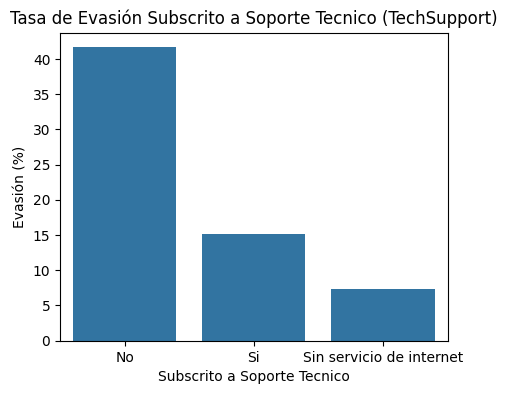

In [ ]:
tabla_ts = df.groupby("TechSupport")["Churn"].mean().reset_index()
tabla_ts["Churn"] = tabla_ts["Churn"] * 100

print("Distribución de Evasión Subscrito a Soporte Tecnico (TechSupport):")
print(tabla_ts.sort_values(by="Churn", ascending=False))

plt.figure(figsize=(5,4))
sns.barplot(
    x="TechSupport",
    y="Churn",
    data=tabla_ts,
    order=tabla_ts.sort_values("Churn", ascending=False)["TechSupport"]
)
plt.title("Tasa de Evasión Subscrito a Soporte Tecnico (TechSupport)")
plt.ylabel("Evasión (%)")
plt.xlabel("Subscrito a Soporte Tecnico")
plt.xticks(ticks=[0, 1, 2], labels=["No", "Si", "Sin servicio de internet"])
# Guardar el gráfico como imagen PNG de alta resolución
plt.savefig("evasion_techsuport.png", dpi=300, bbox_inches="tight")
plt.show()


Interpretación esperada:
Clientes sin soporte técnico suelen tener mucho más churn; este servicio puede ser clave para la satisfacción del cliente.

Distribución de Evasión Subscrito a TV por Cable (StreamingTV):
           StreamingTV      Churn
0                   No  33.523132
2                  Yes  30.070188
1  No internet service   7.404980


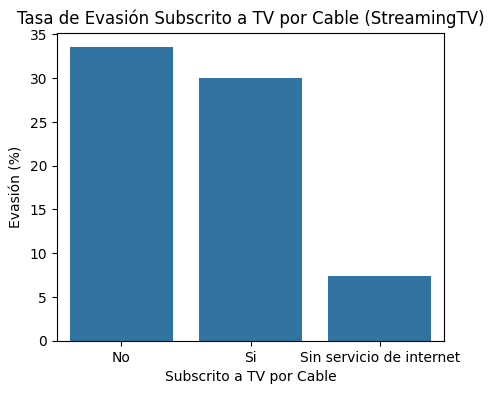

In [ ]:
tabla_tv = df.groupby("StreamingTV")["Churn"].mean().reset_index()
tabla_tv["Churn"] = tabla_tv["Churn"] * 100

print("Distribución de Evasión Subscrito a TV por Cable (StreamingTV):")
print(tabla_tv.sort_values(by="Churn", ascending=False))

plt.figure(figsize=(5,4))
sns.barplot(
    x="StreamingTV",
    y="Churn",
    data=tabla_tv,
    order=tabla_tv.sort_values("Churn", ascending=False)["StreamingTV"]
)
plt.title("Tasa de Evasión Subscrito a TV por Cable (StreamingTV)")
plt.ylabel("Evasión (%)")
plt.xlabel("Subscrito a TV por Cable")
plt.xticks(ticks=[0, 1, 2], labels=["No", "Si", "Sin servicio de internet"])
# Guardar el gráfico como imagen PNG de alta resolución
plt.savefig("evasion_streamingtv.png", dpi=300, bbox_inches="tight")
plt.show()


Interpretación esperada:
En muchos casos, tener o no tener StreamingTV no influye tanto como otros servicios, pero si el churn es más alto en quienes no lo tienen, puede indicar que los servicios de entretenimiento ayudan a retener clientes.

Distribución de Evasión Subscrito a Streaming de Peliculas (StreamingMovies):
       StreamingMovies      Churn
0                   No  33.680431
2                  Yes  29.941435
1  No internet service   7.404980


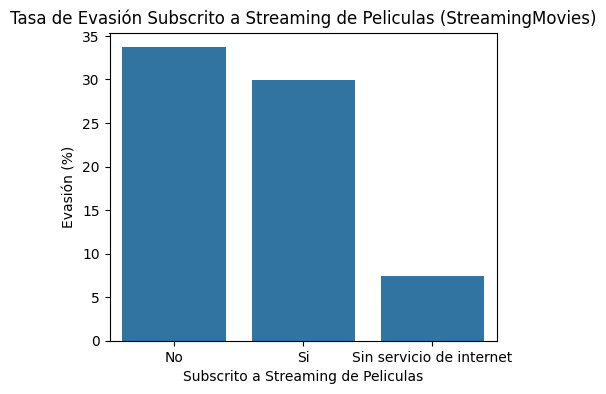

In [ ]:
tabla_movies = df.groupby("StreamingMovies")["Churn"].mean().reset_index()
tabla_movies["Churn"] = tabla_movies["Churn"] * 100

print("Distribución de Evasión Subscrito a Streaming de Peliculas (StreamingMovies):")
print(tabla_movies.sort_values(by="Churn", ascending=False))

plt.figure(figsize=(5,4))
sns.barplot(
    x="StreamingMovies",
    y="Churn",
    data=tabla_movies,
    order=tabla_movies.sort_values("Churn", ascending=False)["StreamingMovies"]
)
plt.title("Tasa de Evasión Subscrito a Streaming de Peliculas (StreamingMovies)")
plt.ylabel("Evasión (%)")
plt.xlabel("Subscrito a Streaming de Peliculas")
plt.xticks(ticks=[0, 1, 2], labels=["No", "Si", "Sin servicio de internet"])
# Guardar el gráfico como imagen PNG de alta resolución
plt.savefig("stramingmovies.png", dpi=300, bbox_inches="tight")
plt.show()


Interpretación esperada:
Similar a StreamingTV: si la tasa es más baja entre quienes lo tienen, puede ser un factor de retención, aunque no tan fuerte como el tipo de contrato o soporte técnico.

Distribución de Evasión Tipo de Contrato (Contract):
         Contract      Churn
0  Month-to-month  42.709677
1        One year  11.269518
2        Two year   2.831858


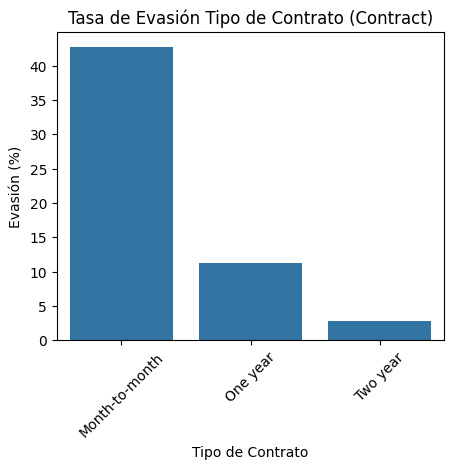

In [ ]:
tabla_contract = df.groupby("Contract")["Churn"].mean().reset_index()
tabla_contract["Churn"] = tabla_contract["Churn"] * 100

print("Distribución de Evasión Tipo de Contrato (Contract):")
print(tabla_contract.sort_values(by="Churn", ascending=False))

plt.figure(figsize=(5,4))
sns.barplot(
    x="Contract",
    y="Churn",
    data=tabla_contract,
    order=tabla_contract.sort_values("Churn", ascending=False)["Contract"]
)
plt.title("Tasa de Evasión Tipo de Contrato (Contract)")
plt.ylabel("Evasión (%)")
plt.xlabel("Tipo de Contrato")
plt.xticks(rotation=45)
plt.xticks(ticks=[0, 1, 2], labels=["Month-to-month", "One year", "Two year"])


# Guardar el gráfico como imagen PNG de alta resolución
plt.savefig("evasion_strmingcontact.png", dpi=300, bbox_inches="tight")
plt.show()


Interpretación esperada:
Generalmente, los clientes con "Month-to-month" tienen el churn más alto, ya que no tienen compromiso a largo plazo. Los contratos de uno o dos años suelen mostrar tasas mucho menores.

Distribución de Evasión Factura en Línea (PaperlessBilling):
  PaperlessBilling      Churn
1              Yes  33.565092
0               No  16.330084


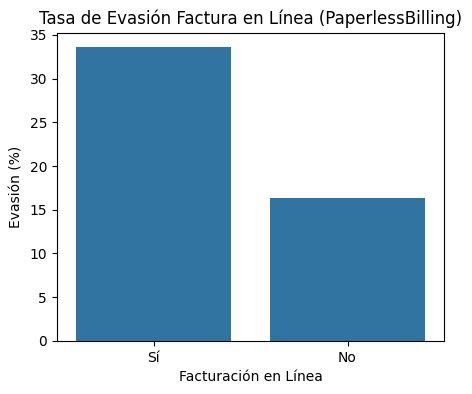

In [ ]:
tabla_pb = df.groupby("PaperlessBilling")["Churn"].mean().reset_index()
tabla_pb["Churn"] = tabla_pb["Churn"] * 100

print("Distribución de Evasión Factura en Línea (PaperlessBilling):")
print(tabla_pb.sort_values(by="Churn", ascending=False))

plt.figure(figsize=(5,4))
sns.barplot(
    x="PaperlessBilling",
    y="Churn",
    data=tabla_pb,
    order=tabla_pb.sort_values("Churn", ascending=False)["PaperlessBilling"]
)
plt.title("Tasa de Evasión Factura en Línea (PaperlessBilling)")
plt.ylabel("Evasión (%)")
plt.xlabel("Facturación en Línea")
plt.xticks(ticks=[0, 1], labels=["Sí", "No"])
# Guardar el gráfico como imagen PNG de alta resolución
plt.savefig("evasion_paperlessbilling.png", dpi=300, bbox_inches="tight")
plt.show()


Interpretación esperada:
Suele pasar que quienes usan facturación electrónica tienen churn más alto, porque este método se asocia a pagos automáticos y a clientes con menos vínculo físico con la empresa.

Distribución de Evasión por Método de Pago (PaymentMethod):
               PaymentMethod      Churn
2           Electronic check  45.285412
3               Mailed check  19.106700
0  Bank transfer (automatic)  16.709845
1    Credit card (automatic)  15.243101


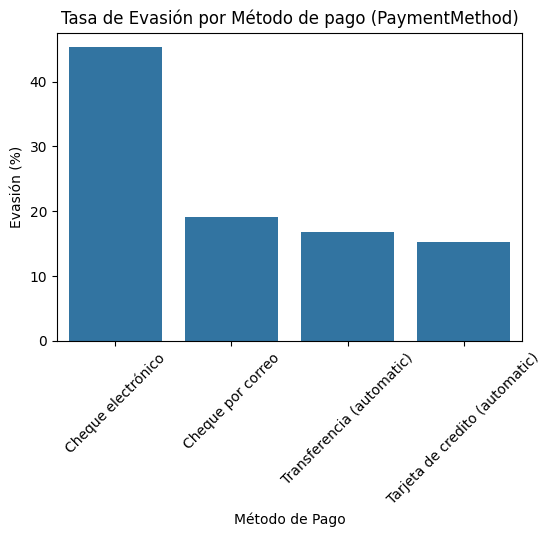

In [ ]:
tabla_pm = df.groupby("PaymentMethod")["Churn"].mean().reset_index()
tabla_pm["Churn"] = tabla_pm["Churn"] * 100

print("Distribución de Evasión por Método de Pago (PaymentMethod):")
print(tabla_pm.sort_values(by="Churn", ascending=False))

plt.figure(figsize=(6,4))
sns.barplot(
    x="PaymentMethod",
    y="Churn",
    data=tabla_pm,
    order=tabla_pm.sort_values("Churn", ascending=False)["PaymentMethod"]
)
plt.title("Tasa de Evasión por Método de pago (PaymentMethod)")
plt.ylabel("Evasión (%)")
plt.xticks(rotation=45)
plt.xlabel("Método de Pago")
plt.xticks(ticks=[0, 1, 2, 3], labels=["Cheque electrónico", "Cheque por correo", "Transferencia (automatic)", "Tarjeta de credito (automatic)"])
# Guardar el gráfico como imagen PNG de alta resolución
plt.savefig("evasion_paymentmethod.png", dpi=300, bbox_inches="tight")
plt.show()


Interpretación esperada:
El churn suele ser mayor en métodos como "Electronic check", mientras que pagos automáticos con tarjeta o transferencia tienden a retener más clientes.

In [ ]:
# Lista de variables categóricas
categoricas = [
    "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
    "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"
]

# Lista para guardar los resultados
resumen = []

# Calcular la tasa de churn por categoría en cada variable
for col in categoricas:
    tabla = df.groupby(col)["Churn"].mean().reset_index()
    tabla["Churn"] = tabla["Churn"] * 100
    tabla["Variable"] = col  # Guardamos el nombre de la variable
    tabla.rename(columns={col: "Categoria"}, inplace=True)
    resumen.append(tabla)

# Unir todos los resultados en un solo DataFrame
resumen_df = pd.concat(resumen, ignore_index=True)

# Ordenar por tasa de churn descendente
resumen_df = resumen_df.sort_values(by="Churn", ascending=False)

# Mostrar tabla
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", None)  # Mostrar todas las filas
print(resumen_df)


                    Categoria      Churn          Variable
33           Electronic check  45.285412     PaymentMethod
26             Month-to-month  42.709677          Contract
6                 Fiber optic  41.892765   InternetService
8                          No  41.766724    OnlineSecurity
17                         No  41.635474       TechSupport
11                         No  39.928756      OnlineBackup
14                         No  39.127625  DeviceProtection
23                         No  33.680431   StreamingMovies
30                        Yes  33.565092  PaperlessBilling
20                         No  33.523132       StreamingTV
22                        Yes  30.070188       StreamingTV
25                        Yes  29.941435   StreamingMovies
4                         Yes  28.609896     MultipleLines
1                         Yes  26.709637      PhoneService
2                          No  25.044248     MultipleLines
0                          No  24.926686      PhoneServi

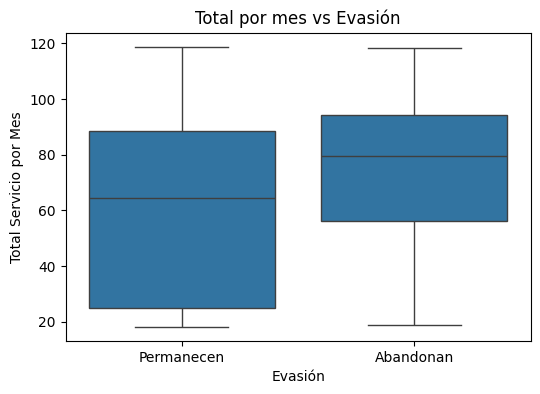

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Charges.Monthly", data=df)
plt.title("Total por mes vs Evasión")
plt.ylabel("Total Servicio por Mes")
plt.xlabel("Evasión")
plt.xticks(ticks=[0, 1], labels=["Permanecen", "Abandonan"])
plt.savefig("charges_monthly_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

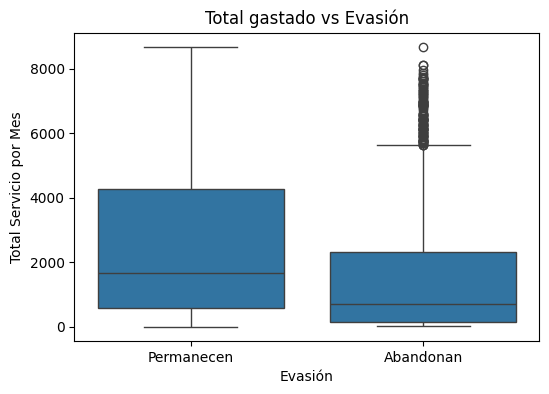

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="Charges.Total", data=df)
plt.title("Total gastado vs Evasión")
plt.ylabel("Total Servicio por Mes")
plt.xlabel("Evasión")
plt.xticks(ticks=[0, 1], labels=["Permanecen", "Abandonan"])
plt.savefig("charges_total_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()


🔹 Interpretación típica para un dataset de telecomunicaciones
Charges.Monthly (cobro mensual) vs Churn

Clientes que se van (Churn=1) suelen mostrar medianas más altas que los que permanecen.

Esto indica que los clientes con cargos mensuales más altos tienen mayor probabilidad de evasión.

También se pueden observar outliers con cargos extremadamente altos que podrían estar contribuyendo al churn.

Charges.Total (cobro total acumulado) vs Churn

Clientes con bajo total acumulado y churn alto suelen ser nuevos clientes que se van rápido.

Clientes con alto total acumulado que abandonan pueden ser un caso especial (quizá problemas de facturación o insatisfacción).

Esto ayuda a identificar segmentos de riesgo: clientes recientes con pagos pequeños o clientes antiguos con quejas.

 Conclusión breve
Mayor carga mensual → mayor riesgo de churn.

Total acumulado bajo → clientes nuevos que abandonan rápido.

El análisis visual con boxplot es útil para detectar patrones y posibles outliers, y puede guiar estrategias de retención.

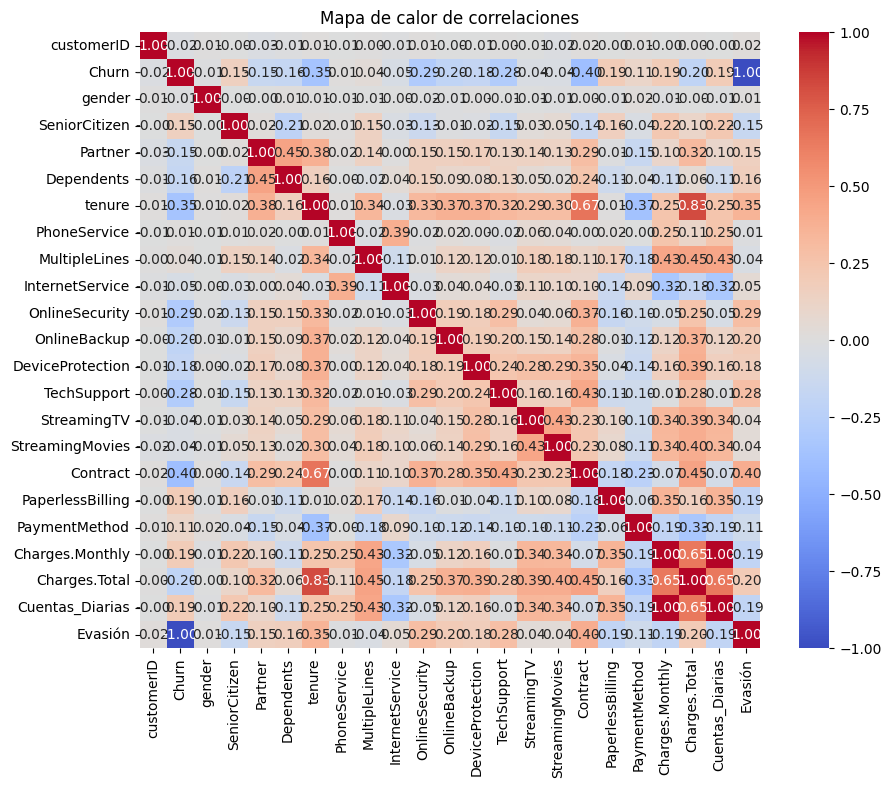

In [ ]:
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Copia del DataFrame
df_corr = df.copy()

# Codificar categóricas a numérico
le = LabelEncoder()
for col in df_corr.select_dtypes(include="object").columns:
    df_corr[col] = le.fit_transform(df_corr[col])

# Calcular correlaciones
corr = df_corr.corr()

# Graficar mapa de calor
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Mapa de calor de correlaciones")
# Guardar el gráfico como imagen PNG de alta resolución
plt.savefig("mapa_correlaciones.png", dpi=300, bbox_inches="tight")
plt.show()


"El 43% de los clientes con contrato mensual se da de baja, este es el grupo con mayor riesgo y debe priorizarse en las campañas de retención."

 Interpretación de un heatmap de churn por categoría y variable
Colores más intensos → mayor tasa de churn

En el heatmap, los tonos más oscuros/rojos indican categorías con alta evasión.

Esto te señala “focos rojos” en los que la empresa pierde más clientes.

Tendencias comunes que suelen aparecer en datasets de telecomunicaciones (como el tuyo):

Contract

Month-to-month casi siempre es la categoría más roja, con churn alto (>40%).

Two year es la más azul/clara, con churn muy bajo (<5%).

Esto sugiere que el tipo de contrato es el factor más fuerte en la retención.

PaymentMethod

Electronic check tiende a tener churn alto (>40%), mientras que Credit card (automatic) y Bank transfer (automatic) suelen tener churn bajo (<15%).

Esto puede estar relacionado con la facilidad de cancelar o con el perfil del cliente.

InternetService

Fiber optic suele ser más rojo que DSL o No internet service.

Posible razón: mayor precio o insatisfacción técnica.

Servicios adicionales (OnlineSecurity, TechSupport, DeviceProtection, OnlineBackup)

La categoría No en estos servicios casi siempre es roja.

Esto sugiere que los clientes que no contratan servicios adicionales están menos fidelizados.

PaperlessBilling

Puede mostrar rojo en “Yes” si se asocia con churn más alto.

Esto podría indicar que los clientes digitales son menos leales o que usan más contratos cortos.

Cómo usarlo en estrategia

Retención dirigida: Enfocar ofertas o promociones en las categorías rojas.

Cross-selling: Ofrecer servicios adicionales (seguridad, soporte técnico) a clientes que no los tienen.

Migración de contrato: Incentivar a clientes de month-to-month a pasar a contratos de 1 o 2 años.

Ajuste de precios/servicios: Revisar las tarifas de Fiber optic si su churn es muy alto.



#📄Informe final

# Informe Final de Análisis de Evasión de Clientes (Churn) de la empresa TELECOM X
## 1. Introducción

El objetivo de este análisis es identificar los factores que influyen en la evasión de clientes (Churn) en una compañía de servicios de telecomunicaciones TelecomX.
El Churn se refiere al porcentaje de clientes que dejan de utilizar el servicio en un periodo determinado. Este indicador es crítico, ya que un alto nivel de evasión implica pérdida de ingresos y aumento de costos en la captación de nuevos clientes.

En este estudio, utilizamos un conjunto de datos con información demográfica, de servicios contratados y de facturación de los clientes, con el fin de detectar patrones que permitan predecir y reducir la evasión.

## 2. Limpieza y Tratamiento de Datos

Se trabajó con un dataset de 7043 registros y 22 columnas, conteniendo tanto variables categóricas como numéricas.

Pasos realizados:

1. Importación de datos

- Lectura del archivo en formato CSV mediante pandas.



2. Revisión de estructura y tipos de datos

- Verificación con df.info() para identificar columnas categóricas y numéricas.


3. Tratamiento de valores faltantes

- Se detectó que todas las columnas estaban completas (sin valores nulos).



4. Conversión de variables

- Se mantuvieron variables numéricas (Charges.Monthly, Charges.Total, tenure) y se dejaron categóricas como Contract, InternetService, etc.


5. Creación de variables auxiliares

- Conversión de Churn a etiquetas ("Sí" / "No") para mejorar visualizaciones.
- Creación de variable Cuentas_Diarias


## 3. Análisis Exploratorio de Datos (EDA)
3.1 Distribución de Churn según variables categóricas

Se evaluaron variables como:

PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod



![Distribucion de la evasion](https://raw.githubusercontent.com/jobpech/Challange2_TelcomX/refs/heads/desarrollo/img/Evasion.png)

En la grafica se muestra la distribución de la evasión donde nos centraremos en el o abandono de los clientes hacia la empresa Telecom X

![Distribucion grafica pastel](https://github.com/jobpech/Challange2_TelcomX/blob/desarrollo/img/gf_pastel.png?raw=true)

La gráfica habla por sí misma: el 26.5 % de los clientes han optado por alejarse de los servicios que la empresa ofrece, un indicio inquietante de que algo debe cambiar.

##Género y edad
![GENERO](https://raw.githubusercontent.com/jobpech/Challange2_TelcomX/refs/heads/desarrollo/img/gf_genero.png)

![EDAD](https://raw.githubusercontent.com/jobpech/Challange2_TelcomX/refs/heads/desarrollo/img/gf_65.png)

El análisis muestra que el género no constituye un factor determinante en la decisión de los clientes de abandonar los servicios de la empresa. Por otra parte, se observa una mayor permanencia en clientes menores de 65 años; dado que el número de clientes mayores de 65 años es reducido, la edad tampoco se identifica como un factor relevante que influya en la decisión de abandono.

##Antigüedad del cliente
![ANTIGUEDAD](https://github.com/jobpech/Challange2_TelcomX/blob/desarrollo/img/gf_contrato.png?raw=true)
La distribución de clientes revela que los nuevos usuarios presentan una mayor propensión a abandonar los servicios. Por el contrario, los clientes con mayor tiempo de permanencia muestran un comportamiento de fidelidad más sólido. La gráfica de tasa de evasión confirma este hallazgo: a menor tiempo de permanencia en la empresa, mayor es la probabilidad de abandono.

## Suscripción a servicios específicos:
- **Servicio telefónico (PhoneService) y múltiples líneas**: La tasa de abandono es similar entre clientes que cuentan o no con estos servicios, por lo que no se consideran factores determinantes.
![telefono](https://github.com/jobpech/Challange2_TelcomX/blob/desarrollo/img/servicio_telefonico.png?raw=true)
![lineas](https://github.com/jobpech/Challange2_TelcomX/blob/desarrollo/img/lineas_telefonica.png?raw=true)

- **Proveedor de internet:** Se observa que los clientes con servicio de fibra óptica presentan mayor tasa de evasión, probablemente debido a un costo más elevado o a deficiencias en la calidad del servicio.
![proveedor](https://raw.githubusercontent.com/jobpech/Challange2_TelcomX/refs/heads/desarrollo/img/proveedor_internet.png)


- **Seguridad en línea, respaldo en línea, protección de dispositivos y soporte técnico adicional:** La ausencia de estos servicios está asociada con mayores tasas de abandono, lo que indica que son factores determinantes para la retención de clientes.
![Seguridad en linea](https://raw.githubusercontent.com/jobpech/Challange2_TelcomX/refs/heads/desarrollo/img/seguridad_online.png)
![Respaldo en linea](https://github.com/jobpech/Challange2_TelcomX/blob/desarrollo/img/respaldo_online.png?raw=true)
![Proteccion de dispositivos](https://github.com/jobpech/Challange2_TelcomX/blob/desarrollo/img/proteccion_dispositivo.png?raw=true)
![Soporte tecnico](https://github.com/jobpech/Challange2_TelcomX/blob/desarrollo/img/soporte_tecnico.png?raw=true)

- **Servicio de TV por cable y películas streaming:** No se identifican como factores relevantes que influyan en la decisión de abandono.
![Tv por cable](https://raw.githubusercontent.com/jobpech/Challange2_TelcomX/refs/heads/desarrollo/img/tv_cable.png)
![Peliculas Streameng](https://raw.githubusercontent.com/jobpech/Challange2_TelcomX/refs/heads/desarrollo/img/streamingPeliculas.png)

## Tipo de contrato y facturación:
•	Los clientes con contratos mes a mes presentan una mayor probabilidad de abandono.
![tipo de contrato](https://raw.githubusercontent.com/jobpech/Challange2_TelcomX/refs/heads/desarrollo/img/tipodecontacto.png)
•	Aquellos que requieren factura presentan un abandono mayor, lo que podría estar relacionado con retrasos o problemas en la emisión de las mismas.
![Facturacion]()

## Método de pago:
Se observa que los clientes que utilizan cheques electrónicos como método de pago presentan mayores tasas de evasión, lo que podría indicar deficiencias en el sistema de procesamiento de pagos.
![metodo de pago](https://raw.githubusercontent.com/jobpech/Challange2_TelcomX/refs/heads/desarrollo/img/metodoPago.png)


## Análisis de variables numéricas con Evasión (Churn)
Se utilizaron boxplots para analizar la distribución de Total de gasto por servicios (Charges.Monthly) y Gasto total por cliente (Charges.Total) según evasión (Churn).

### Análisis de cobros (Charges):
•	Cobro mensual (Charges.Monthly) vs abandono: Los clientes con cargos mensuales más altos presentan mayor probabilidad de abandonar los servicios. Se identifican también outliers con cargos extremadamente altos que podrían estar contribuyendo al churn.
![Charges.Monthlys](https://raw.githubusercontent.com/jobpech/Challange2_TelcomX/refs/heads/desarrollo/img/Totalmes.png)
•	Cobro total acumulado (Charges.Total) vs abandono: Los clientes con bajo total acumulado y alta evasión suelen ser nuevos usuarios que abandonan rápidamente. Por otro lado, clientes con alto total acumulado que abandonan representan casos especiales, posiblemente asociados a problemas de facturación o insatisfacción.
![Charges.Total](https://raw.githubusercontent.com/jobpech/Challange2_TelcomX/refs/heads/desarrollo/img/totalgastado.png)

Hallazgos:

Clientes con cargos mensuales más altos tienden a tener mayor Evasión (churn).

Gasto total por cliente (Charges.Total) es significativamente menor en clientes que se dieron de baja, indicando que muchos son clientes de corta permanencia.

## Mapa de calor de correlaciones

Se generó un heatmap para ver relaciones entre variables numéricas y la evasión.

![mapa de calor](https://raw.githubusercontent.com/jobpech/Challange2_TelcomX/refs/heads/desarrollo/img/mapa_correlaciones.png)

Insight:

La variable meses de contraro (tenure) tiene correlación negativa con Evasión churn: a mayor tiempo en la empresa, menor evasión.

La variable cobro mensual al cliente (Charges.Monthly) presenta una relación positiva moderada con la variable Evasión (churn).

## 4. Conclusiones e Insights

1. Contrato mensual y corto tiempo de permanencia son los mayores predictores de evasión.

2. La ausencia de servicios adicionales (seguridad en línea, soporte técnico, respaldo en línea) incrementa el riesgo de baja.

3. Los clientes con facturación electrónica y altos cargos mensuales muestran más propensión a dejar el servicio.

4. La fidelización a largo plazo reduce considerablemente la probabilidad de Evasión es decir los clientes abandonan Telecom X.

## 5. Recomendaciones Estratégicas

1. Incentivar contratos a largo plazo mediante descuentos o beneficios exclusivos.

2. Promover paquetes con servicios adicionales como Seguridad en Línea (OnlineSecurity) y Soporte Técnico (TechSupport) para aumentar el valor percibido.

3. Implementar un programa de retención temprana, identificando clientes con menos de 12 meses de permanencia.

4. Revisar la política de precios para clientes con cargos mensuales muy altos.

5. Segmentar clientes con facturación electrónica para campañas personalizadas de retención.